# Johansen Cointegration Test + Conditional VECM (Issue #47)
**DAMO-699 Capstone Project, Group 5**

## 1. Introduction & Motivation

Both VAR baselines fail to beat the naïve Random Walk benchmark at any forecast horizon:
- **VAR-AIC** (lag=10, issue #28): naïve significantly better at h=1 on MAE (p=0.0005)
- **VAR-BIC** (lag=0, issue #29): reduces to a drift model; naïve significantly better at h=1 on MAE (p=0.0124)

Pure differencing discards any long-run equilibrium information. If the level series share cointegrating relationships, the Error Correction Term (ECT) in a VECM may recover predictive signal that the differenced VAR cannot access.

> **Decision Justification:** This analysis is the next logical step in the modeling pipeline per the proposal §5.2 commitment and the dependency chain from `SPRINT_AUG21_RECOVERY.md`. The Johansen test screens for equilibrium relationships; only if they exist (r ≥ 1) is VECM estimation warranted.

In [1]:
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=Warning, module="statsmodels")

# Add project root to path
PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from src.johansen_vecm import (
    load_gold_levels, confirm_i1, select_lag_levels,
    run_johansen_all_specs, fit_and_summarize_vecm,
    evaluate_vecm, dm_report_vecm,
    FEATURE_SET_5VAR, FEATURE_SET_6VAR, JOHANSEN_SPECS,
    TARGET, HORIZONS, MAX_LAG_SEARCH, MIN_TRAIN, STEP, ALPHA,
)
from statsmodels.tsa.api import VAR

print("Setup complete.")

Setup complete.


## 2. Variable Selection

### Primary System: 5 Variables
`yield_spread_10y_2y` (target), `overnight_rate`, `us_treasury_10y`, `fed_funds_rate`, `cpi_yoy`

> **Decision Justification:** The same 5-variable system used by both VAR baselines (issues #28, #29). This ensures direct comparability — the VECM and VARs operate on the identical information set, so any performance difference is attributable to the error correction mechanism, not to variable selection. Additionally, Johansen tests lose power rapidly as system dimension grows relative to sample size; with n≈4,268, a 5-variable system preserves adequate statistical power.

### Robustness Check: 6 Variables (+ usdcad)

> **Decision Justification:** The USD/CAD exchange rate is the key international transmission channel for Canadian yields given the tight Canada-US economic linkage. Adding it tests whether cross-border dynamics introduce cointegrating relationships absent in the domestic-only system.

## 3. Data Loading & Input Series

> **Decision Justification — Raw Level Series:** The Johansen (1991) procedure is specifically designed to detect long-run equilibrium relationships among **non-stationary I(1) variables in levels**. Applying it to already-differenced I(0) series would test for cointegration among stationary variables, which is not meaningful. The EDA notebook (`01_eda`) confirmed all 5 series are I(1).

> **Decision Justification — Gold-layer CSV:** Loading from the canonical `data/processed/gold_features.csv` ensures a single validated source with zero nulls, release-date-aligned CPI (no lookahead bias), and cross-border holiday alignment (outer join with ffill limit=2).

In [2]:
levels = load_gold_levels(FEATURE_SET_5VAR)
print(f"Shape: {levels.shape}")
print(f"Date range: {levels.index.min().date()} to {levels.index.max().date()}")
levels.describe()

Shape: (4268, 5)
Date range: 2010-02-19 to 2026-06-30


,yield_spread_10y_2y,overnight_rate,us_treasury_10y,fed_funds_rate,cpi_yoy
count,4268.000000,4268.000000,4268.000000,4268.000000,4268.000000
mean,0.567167,1.552952,2.654789,1.494304,2.294500
std,0.677482,1.377425,1.029123,1.827008,1.524980
min,-1.320000,0.250000,0.520000,0.040000,-0.366032
25%,0.190000,0.500000,1.880000,0.100000,1.319876
50%,0.670000,1.000000,2.500000,0.370000,1.987768
75%,0.990000,1.750000,3.450000,2.400000,2.739726
max,2.120000,5.000000,4.980000,5.330000,8.132956


## 4. Stationarity Confirmation (ADF Tests)

> **Decision Justification:** ADF confirmation is a prerequisite for Johansen testing. The procedure assumes all variables are I(1): including an I(0) variable would inflate the estimated cointegration rank, while including an I(2) variable violates the test's asymptotic theory. We verify both conditions: non-stationarity in levels (p ≥ 0.05) AND stationarity in first differences (p < 0.05).

In [3]:
adf_results = confirm_i1(levels)
adf_results

  5/5 series confirmed I(1).
    yield_spread_10y_2y        p_level=0.2525  p_diff=0.0000  [I(1)]
    overnight_rate             p_level=0.6268  p_diff=0.0000  [I(1)]
    us_treasury_10y            p_level=0.6474  p_diff=0.0000  [I(1)]
    fed_funds_rate             p_level=0.7988  p_diff=0.0000  [I(1)]
    cpi_yoy                    p_level=0.2365  p_diff=0.0000  [I(1)]


,variable,adf_p_level,adf_p_diff,I1_confirmed
0,yield_spread_10y_2y,0.2525,0.0,True
1,overnight_rate,0.6268,0.0,True
2,us_treasury_10y,0.6474,0.0,True
3,fed_funds_rate,0.7988,0.0,True
4,cpi_yoy,0.2365,0.0,True


## 5. Lag Order Selection (Levels VAR)

> **Decision Justification — Independent Lag Selection:** The VAR baseline (issue #28) selected lag p=10 by AIC on the **differenced** system. However, the Johansen test operates on a VAR in **levels**, where p lags in levels correspond to p−1 lags in the VECM representation (Lütkepohl, 2005). The optimal lag order can differ between levels and differences, so we perform independent AIC/BIC/HQIC selection on the level series up to maxlags=15.

In [4]:
aic_lag_levels, order_results = select_lag_levels(levels)
k_ar_diff = max(1, aic_lag_levels - 1)

# Differenced-VAR lag orders for the two comparison baselines (VAR-AIC, VAR-BIC)
diffed = levels.diff().dropna()
diffed.columns = [f"d_{c}" for c in levels.columns]
diff_order_results = VAR(diffed).select_order(maxlags=MAX_LAG_SEARCH)
aic_lag_diff = max(1, diff_order_results.aic)
bic_lag_diff = diff_order_results.bic  # can be 0 (drift model)

print(f"\nLevels VAR AIC lag: {aic_lag_levels} \u2192 VECM k_ar_diff = {k_ar_diff}")
print(f"Differenced VAR AIC lag: {aic_lag_diff}, BIC lag: {bic_lag_diff} (comparison baselines)")


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -3.516      -3.509     0.02970      -3.514
1       -31.34     -31.30*   2.440e-14      -31.33
2       -31.35      -31.27   2.432e-14      -31.32
3       -31.34      -31.22   2.439e-14      -31.30
4       -31.35      -31.19   2.431e-14      -31.29
5       -31.35      -31.16   2.426e-14      -31.28
6       -31.37      -31.13   2.388e-14      -31.28
7       -31.36      -31.09   2.399e-14      -31.27
8       -31.36      -31.05   2.406e-14      -31.25
9       -31.36      -31.01   2.411e-14      -31.23
10      -31.35      -30.97   2.419e-14      -31.22
11     -31.49*      -31.07  2.118e-14*     -31.34*
12      -31.49      -31.03   2.118e-14      -31.32
13      -31.48      -30.99   2.126e-14      -31.31
14      -31.48      -30.95   2.134e-14      -31.29
15      -31.47      -30.91   2.142e-14      -31.27
-------------------------------


Levels VAR AIC lag: 11 → VECM k_ar_diff = 10
Differenced VAR AIC lag: 11, BIC lag: 0 (comparison baselines)


## 6. Johansen Cointegration Test

> **Decision Justification — Three Deterministic Specifications:** We test all three deterministic cases supported by `statsmodels.coint_johansen` (det_order ∈ {-1, 0, 1}), corresponding to: (1) no deterministic terms, (2) restricted constant in the cointegrating equation, (3) restricted constant + restricted linear trend. This provides academic rigor (Pantula principle) while avoiding cherry-picking a single specification.

> **Decision Justification — Trace Statistic as Primary Criterion:** The trace test has better small-sample power properties than the maximum eigenvalue test (Lütkepohl, Saikkonen & Trenkler, 2001) and is the more commonly used in applied macro-finance. The max eigenvalue statistic is reported for transparency but the trace statistic governs the rank decision. The **restricted constant** (det_order=0) is the primary specification — interest rates and yield spreads exhibit mean reversion toward a shifting equilibrium driven by monetary policy cycles.

In [5]:
johansen_df, primary_rank = run_johansen_all_specs(levels, k_ar_diff)
print(f"\n{'='*50}")
print(f"PRIMARY RESULT: Cointegration rank r = {primary_rank}")
print(f"{'='*50}")


  det_order=-1  (No deterministic terms)
    Trace rank: r=1,  Max-Eig rank: r=3  [DISAGREE]
    H0: r<=0:  trace=    79.19  cv_95=   60.06  -> REJECT
    H0: r<=1:  trace=    29.85  cv_95=   40.17  -> fail to reject
    H0: r<=2:  trace=    16.64  cv_95=   24.28  -> fail to reject
    H0: r<=3:  trace=     2.07  cv_95=   12.32  -> fail to reject
    H0: r<=4:  trace=     0.03  cv_95=    4.13  -> fail to reject

  det_order=+0  (Restricted constant (intercept in CE only))
    Trace rank: r=1,  Max-Eig rank: r=3  [DISAGREE]
    H0: r<=0:  trace=    87.61  cv_95=   69.82  -> REJECT
    H0: r<=1:  trace=    30.26  cv_95=   47.85  -> fail to reject
    H0: r<=2:  trace=    17.01  cv_95=   29.80  -> fail to reject
    H0: r<=3:  trace=     5.11  cv_95=   15.49  -> fail to reject
    H0: r<=4:  trace=     0.39  cv_95=    3.84  -> fail to reject

  det_order=+1  (Restricted constant + restricted linear trend)
    Trace rank: r=1,  Max-Eig rank: r=3  [DISAGREE]
    H0: r<=0:  trace=    87.61 

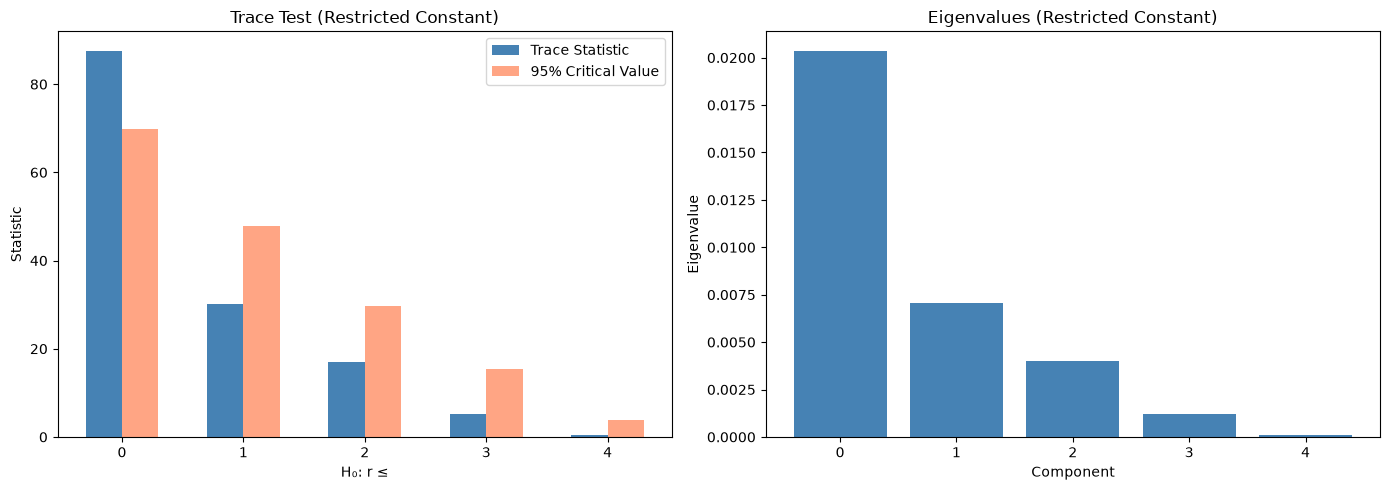

In [6]:
# Eigenvalue bar chart for primary specification (det_order=0)
primary = johansen_df[johansen_df["det_order"] == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trace statistics vs critical values
ax = axes[0]
r_nulls = primary["r_null"].values
ax.bar(r_nulls - 0.15, primary["trace_stat"], width=0.3, label="Trace Statistic", color="steelblue")
ax.bar(r_nulls + 0.15, primary["trace_cv_95"], width=0.3, label="95% Critical Value", color="coral", alpha=0.7)
ax.set_xlabel("H₀: r ≤")
ax.set_ylabel("Statistic")
ax.set_title("Trace Test (Restricted Constant)")
ax.set_xticks(r_nulls)
ax.legend()

# Eigenvalues
ax = axes[1]
ax.bar(range(len(primary)), primary["eigenvalue"].values, color="steelblue")
ax.set_xlabel("Component")
ax.set_ylabel("Eigenvalue")
ax.set_title("Eigenvalues (Restricted Constant)")
ax.set_xticks(range(len(primary)))

plt.tight_layout()
plt.show()

## 7. VECM Estimation

This section executes **conditionally**: only if the Johansen test found cointegrating vectors (r ≥ 1) under the primary specification.

If r ≥ 1, we estimate a VECM and extract:
- **Cointegrating vectors (β):** The long-run equilibrium relationships
- **Adjustment coefficients (α):** The speed at which each variable corrects deviations from equilibrium
- **Error Correction Terms (ECT):** The time series of deviations from long-run equilibrium

In [7]:
if primary_rank >= 1:
    det_spec = JOHANSEN_SPECS[0]["vecm_det"]
    vecm_fit = fit_and_summarize_vecm(levels, k_ar_diff, primary_rank, det_spec)
else:
    print("r = 0: No cointegrating vectors found. VECM not estimated.")
    print("\nThis is a SUBSTANTIVE FINDING — see Section 10 for interpretation.")

Det. terms outside the coint. relation & lagged endog. parameters for equation yield_spread_10y_2y
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
L1.yield_spread_10y_2y     -0.0483      0.017     -2.818      0.005      -0.082      -0.015
L1.overnight_rate           0.0022      0.013      0.171      0.864      -0.023       0.028
L1.us_treasury_10y          0.0134      0.009      1.417      0.156      -0.005       0.032
L1.fed_funds_rate           0.0062      0.012      0.522      0.602      -0.017       0.030
L1.cpi_yoy                  0.0046      0.005      0.942      0.346      -0.005       0.014
L2.yield_spread_10y_2y      0.0028      0.017      0.163      0.871      -0.031       0.036
L2.overnight_rate           0.0001      0.013      0.011      0.992      -0.025       0.025
L2.us_treasury_10y          0.0057      0.009      0.601      0.548      

## 8. Forecast Evaluation

> **Decision Justification — Same Expanding-Window Protocol:** We use MIN_TRAIN=500, STEP=5, horizons h ∈ {1, 5, 20} trading days, with evaluation in levels (not differences) per proposal §5.4. This ensures apples-to-apples comparability with both VAR baselines.

> **Decision Justification — 4-Way DM Comparison:** Testing VECM against (1) naïve random walk (absolute benchmark), (2) VAR-AIC (best-fit differenced model, lag=10), and (3) VAR-BIC (most parsimonious differenced model, lag=0/drift) isolates whether the Error Correction Term adds predictive value above and beyond each alternative. The Diebold-Mariano test uses Harvey correction and Bartlett-kernel long-run variance estimation, matching the existing baselines.

In [8]:
if primary_rank >= 1:
    det_spec = JOHANSEN_SPECS[0]["vecm_det"]
    eval_metrics, eval_raw, eval_forecasts = evaluate_vecm(
        levels=levels, diffed=diffed, k_ar_diff=k_ar_diff, coint_rank=primary_rank,
        det_spec=det_spec, aic_lag_diff=aic_lag_diff, bic_lag_diff=bic_lag_diff,
    )
    display(eval_metrics)
else:
    print("Skipped: no VECM to evaluate (r = 0).")


    ... 100 origins evaluated  (23%)


    ... 200 origins evaluated  (35%)


    ... 300 origins evaluated  (47%)


    ... 400 origins evaluated  (59%)


    ... 500 origins evaluated  (71%)


    ... 600 origins evaluated  (82%)


    ... 700 origins evaluated  (94%)


  Completed: 750 origins, 0 failures skipped.


,horizon_days,n_forecasts,rmse_vecm,mae_vecm,rmse_var_aic,mae_var_aic,rmse_var_bic,mae_var_bic,rmse_naive,mae_naive,vecm_beats_naive_rmse,vecm_beats_naive_mae,vecm_beats_var_aic_rmse,vecm_beats_var_aic_mae,vecm_beats_var_bic_rmse,vecm_beats_var_bic_mae
0,1,750,0.029879,0.021568,0.029806,0.021404,0.029010,0.020664,0.029001,0.020587,False,False,False,False,False,False
1,5,750,0.063771,0.048123,0.063842,0.048084,0.061354,0.046628,0.061161,0.046333,False,False,True,False,False,False
2,20,750,0.125032,0.094888,0.125838,0.095791,0.126534,0.095683,0.125057,0.094387,True,False,True,True,True,True


In [9]:
if primary_rank >= 1:
    dm_results = dm_report_vecm(eval_raw)
    display(dm_results)
else:
    print("Skipped: no DM tests (r = 0).")

,horizon_days,dm_vecm_naive_stat_sq,dm_vecm_naive_p_sq,dm_vecm_naive_stat_abs,dm_vecm_naive_p_abs,vecm_sig_better_naive_rmse,naive_sig_better_vecm_rmse,vecm_sig_better_naive_mae,naive_sig_better_vecm_mae,dm_vecm_var_aic_stat_sq,...,vecm_sig_better_var_aic_mae,var_aic_sig_better_vecm_mae,dm_vecm_var_bic_stat_sq,dm_vecm_var_bic_p_sq,dm_vecm_var_bic_stat_abs,dm_vecm_var_bic_p_abs,vecm_sig_better_var_bic_rmse,var_bic_sig_better_vecm_rmse,vecm_sig_better_var_bic_mae,var_bic_sig_better_vecm_mae
0,1,3.214,0.0014,4.246,0.0000,False,True,False,True,0.726,...,False,False,3.173,0.0016,3.950,0.0001,False,True,False,True
1,5,2.278,0.0230,2.459,0.0141,False,True,False,True,-0.155,...,False,False,2.144,0.0324,2.042,0.0415,False,True,False,True
2,20,-0.008,0.9936,0.237,0.8130,False,False,False,False,-0.321,...,False,False,-0.468,0.6396,-0.314,0.7538,False,False,False,False


## 9. Robustness Check: 6-Variable System (+ usdcad)

> **Decision Justification:** Adding `usdcad` tests whether cross-border exchange rate dynamics introduce cointegrating relationships absent in the 5-variable domestic system. The USD/CAD exchange rate is the primary international transmission channel for Canadian interest rates.

In [10]:
print("Loading 6-variable system...")
levels_6 = load_gold_levels(FEATURE_SET_6VAR)
print(f"Shape: {levels_6.shape}")

print("\nADF tests...")
adf_6 = confirm_i1(levels_6)

print("\nLag selection...")
aic_lag_6, _ = select_lag_levels(levels_6)
k_ar_diff_6 = max(1, aic_lag_6 - 1)

print("\nJohansen test...")
johansen_6, rank_6 = run_johansen_all_specs(levels_6, k_ar_diff_6)
print(f"\n6-var cointegration rank: r = {rank_6}")

if rank_6 >= 1:
    diffed_6 = levels_6.diff().dropna()
    diffed_6.columns = [f"d_{c}" for c in levels_6.columns]
    diff_order_6 = VAR(diffed_6).select_order(maxlags=MAX_LAG_SEARCH)
    aic_diff_6 = max(1, diff_order_6.aic)
    bic_diff_6 = diff_order_6.bic
    det_6 = JOHANSEN_SPECS[0]["vecm_det"]
    vecm_6 = fit_and_summarize_vecm(levels_6, k_ar_diff_6, rank_6, det_6)
    metrics_6, raw_6, forecasts_6 = evaluate_vecm(
        levels=levels_6, diffed=diffed_6, k_ar_diff=k_ar_diff_6, coint_rank=rank_6,
        det_spec=det_6, aic_lag_diff=aic_diff_6, bic_lag_diff=bic_diff_6,
    )
    display(metrics_6)
    dm_6 = dm_report_vecm(raw_6)
    display(dm_6)
else:
    print("r = 0 in 6-var system as well \u2014 no VECM estimated.")


Loading 6-variable system...
Shape: (4268, 6)

ADF tests...


  6/6 series confirmed I(1).
    yield_spread_10y_2y        p_level=0.2525  p_diff=0.0000  [I(1)]
    overnight_rate             p_level=0.6268  p_diff=0.0000  [I(1)]
    us_treasury_10y            p_level=0.6474  p_diff=0.0000  [I(1)]
    fed_funds_rate             p_level=0.7988  p_diff=0.0000  [I(1)]
    cpi_yoy                    p_level=0.2365  p_diff=0.0000  [I(1)]
    usdcad                     p_level=0.6789  p_diff=0.0000  [I(1)]

Lag selection...


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -8.899      -8.890   0.0001365      -8.896
1       -41.80     -41.74*   6.991e-19     -41.78*
2       -41.81      -41.69   6.971e-19      -41.77
3       -41.80      -41.63   6.992e-19      -41.74
4       -41.81      -41.58   6.979e-19      -41.73
5       -41.81      -41.53   6.967e-19      -41.71
6       -41.82      -41.49   6.863e-19      -41.71
7       -41.81      -41.43   6.923e-19      -41.68
8       -41.81      -41.37   6.958e-19      -41.65
9       -41.81      -41.31   6.976e-19      -41.63
10      -41.80      -41.25   7.027e-19      -41.61
11     -41.93*      -41.33  6.148e-19*      -41.72
12      -41.93      -41.28   6.163e-19      -41.70
13      -41.92      -41.22   6.198e-19      -41.67
14      -41.92      -41.15   6.248e-19      -41.65
15      -41.91      -41.09   6.286e-19      -41.62
-------------------------------

Det. terms outside the coint. relation & lagged endog. parameters for equation yield_spread_10y_2y
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
L1.yield_spread_10y_2y     -0.0483      0.017     -2.820      0.005      -0.082      -0.015
L1.overnight_rate           0.0019      0.013      0.143      0.886      -0.024       0.027
L1.us_treasury_10y          0.0141      0.009      1.488      0.137      -0.004       0.033
L1.fed_funds_rate           0.0058      0.012      0.487      0.626      -0.018       0.029
L1.cpi_yoy                  0.0049      0.005      0.987      0.323      -0.005       0.015
L1.usdcad                   0.0774      0.083      0.937      0.349      -0.084       0.239
L2.yield_spread_10y_2y      0.0018      0.017      0.106      0.915      -0.032       0.036
L2.overnight_rate          -0.0002      0.013     -0.019      0.985      

    ... 100 origins evaluated  (23%)


...

    ... 600 origins evaluated  (82%)


    ... 700 origins evaluated  (94%)


  Completed: 750 origins, 0 failures skipped.


,horizon_days,n_forecasts,rmse_vecm,mae_vecm,rmse_var_aic,mae_var_aic,rmse_var_bic,mae_var_bic,rmse_naive,mae_naive,vecm_beats_naive_rmse,vecm_beats_naive_mae,vecm_beats_var_aic_rmse,vecm_beats_var_aic_mae,vecm_beats_var_bic_rmse,vecm_beats_var_bic_mae
0,1,750,0.029729,0.021491,0.029757,0.021522,0.029010,0.020664,0.029001,0.020587,False,False,True,True,False,False
1,5,750,0.063507,0.047840,0.063621,0.048111,0.061354,0.046628,0.061161,0.046333,False,False,True,True,False,False
2,20,750,0.123891,0.093428,0.125712,0.095770,0.126534,0.095683,0.125057,0.094387,True,True,True,True,True,True


,horizon_days,dm_vecm_naive_stat_sq,dm_vecm_naive_p_sq,dm_vecm_naive_stat_abs,dm_vecm_naive_p_abs,vecm_sig_better_naive_rmse,naive_sig_better_vecm_rmse,vecm_sig_better_naive_mae,naive_sig_better_vecm_mae,dm_vecm_var_aic_stat_sq,...,vecm_sig_better_var_aic_mae,var_aic_sig_better_vecm_mae,dm_vecm_var_bic_stat_sq,dm_vecm_var_bic_p_sq,dm_vecm_var_bic_stat_abs,dm_vecm_var_bic_p_abs,vecm_sig_better_var_bic_rmse,var_bic_sig_better_vecm_rmse,vecm_sig_better_var_bic_mae,var_bic_sig_better_vecm_mae
0,1,2.427,0.0155,3.648,0.0003,False,True,False,True,-0.329,...,False,False,2.384,0.0174,3.371,0.0008,False,True,False,True
1,5,2.217,0.0269,2.157,0.0313,False,True,False,True,-0.283,...,False,False,2.096,0.0364,1.743,0.0817,False,True,False,False
2,20,-0.377,0.7064,-0.464,0.6431,False,False,False,False,-0.806,...,False,False,-0.888,0.3751,-0.951,0.3419,False,False,False,False


## 10. Negative Result Documentation (if r = 0)

> **Decision Justification:** A negative result (no cointegration) is reported as a **substantive finding**, not an open item. Per the issue description: *"If no cointegration is found, document that explicitly — a negative result here is still a result, not an open item."*
>
> If the 5 core macro-financial variables do not share a long-run equilibrium, this is economically informative: the yield spread may not revert to a stable relationship with these fundamentals over the 2010–2026 sample. Possible explanations include:
> - **Structural breaks:** Quantitative Easing (2010–2014), COVID shock (2020), aggressive rate hiking cycle (2022–2023)
> - **Regime changes:** The Bank of Canada's forward guidance and unconventional monetary policy tools may have altered the yield curve's equilibrium dynamics
> - **Genuine absence of cointegration:** The variables may be driven by independent non-stationary processes without a common stochastic trend
>
> This result also has implications for the downstream modeling pipeline: if VECM adds no value, the focus shifts to non-linear models (LSTM, issue #49) and the Diebold-Mariano comparison across all models (issue #50).

## 11. Conclusion

This notebook implemented the Johansen cointegration test and conditional VECM estimation as committed in the project proposal (§5.2) and tracked in issue #47.

**Key findings are documented in the output CSVs:**
- `outputs/johansen_cointegration_results.csv` — Full Johansen test results
- `outputs/johansen_lag_selection.csv` — Lag selection results
- `outputs/vecm_rmse_mae_vs_naive.csv` — VECM forecast metrics (if estimated)
- `outputs/vecm_diebold_mariano.csv` — DM significance tests (if estimated)

**Next steps in the dependency chain:**
- IRF / FEVD / Granger causality (issue #48)
- ARIMA baseline
- LSTM + SHAP (issue #49)
- Diebold-Mariano across all models (issue #50)